Pipeline for segmentation and tracking of cell imaging data (TSBL)
1. Always switch to T4 GPU when running CellPose SAM models. Segmented files may be saved after which runtime may be changed to CPU to run Bayesian tracker.
2. Upload .tif files without channel data for segmentation. Segmentation is done in greyscale.
3. Segmented files can be downloaded directly from the directory or zipped as needed.
4. Segmented files require to be merged for different channels for one time point and then combined for multiple time points in one .tif file for Bayesian tracker.
Such an exercise can be done using software like ImageJ.
5. Upload compiled .tif file to run Bayesian tracker.
Output is a .h5 file that can be exported. Datastrucutre of the .h5 file can be understood using tools present at the end of the script.

Install CellPose SAM from Github and Bayesian Tracker as package.

In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-im1s_g9y
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-im1s_g9y
  Resolved https://www.github.com/mouseland/cellpose.git to commit 4fbdc7cc5ec34c38c14258ac0e869a6bd802f3ca
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 80.4 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.9.dev7+g4fbdc7cc5-py3-none-any.whl size=212309 sha256=3248af7d4964fbe0f1b21f883abfcec1cc7d6219c741dc78fef2c057503800cf
  Stored in directory: /tmp/pip-ephem-wheel-cache-oa8367vi/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


In [ ]:
!pip install btrack

Upload files that need to be segmented from desktop.

(Works best for .tif files)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PXL_20260210_055820531~2.jpg to PXL_20260210_055820531~2.jpg


Import necessary libraries.

In [ ]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import os
#import btrack
from skimage.io import imread
import zipfile
import h5py

Check for uploaded files in local directory and download Cellpose GPU model.

Please ensure T4 GPU is selected for runtime.

In [ ]:
print("Files in current directory:", os.listdir()) #Displays file in current directory
model = models.CellposeModel(gpu=True) #Downloads desired cellpose model
dir = Path(".") #Set local directory
files = natsorted([f for f in dir.glob("*"+".jpg") if "_masks" not in f.name and "_flows" not in f.name])
print(f"{len(files)} files present:") #Displays files that are present
for f in files:
  print(f.name)

Files in current directory: ['.config', 'PXL_20260210_055820531~2.jpg', 'sample_data']


100%|██████████| 1.15G/1.15G [00:16<00:00, 73.6MB/s]


1 files present:
PXL_20260210_055820531~2.jpg


Loops through all images present in local directory. (All images will be processed in grayscale.)

Segmented panels will be given as code output, segmented mask .tif files will be present in local directory.

  0%|          | 0/1 [00:00<?, ?it/s]

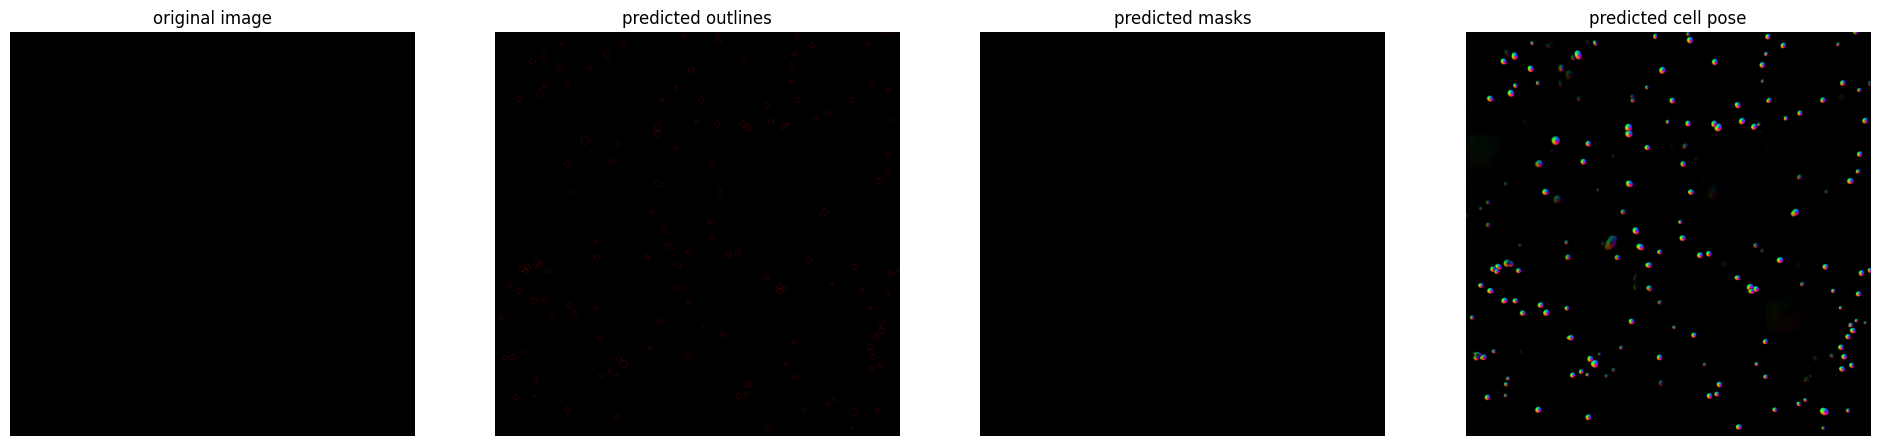

100%|██████████| 1/1 [00:53<00:00, 53.60s/it]


In [ ]:
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    np.zeros_like(img)[:, :] = img[:, :] #Converts image files into two dimensions.
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=0.4, cellprob_threshold=0.0,
                                  normalize={"tile_norm_blocksize": 0})

#Makes panels as seen in the immediate output.
    plot.show_segmentation(plt.figure(figsize = (24,10)), np.zeros_like(img), masks, flows[0])
    plt.show()
    io.imsave(dir / (f.stem + "_masks" + ".jpg"), masks) #Saves mask files as tifs in local directory.

Downloads all masks in directory as a zip file, if required.

(One can choose to donwload files manually from the directory as well.)

In [ ]:
matching_files = [f for f in os.listdir('.') if 'masks' in f] #Searches for mask files.
print("Files to zip:")
for f in matching_files:
    print(f) #Displays files that will be zipped. Non-essential to function.
with zipfile.ZipFile('processed_files.zip', 'w') as zipf:
    for file in matching_files:
        full_path = os.path.join('.', file)
        zipf.write(full_path, arcname=file)  # arcname avoids full path in zip

from google.colab import files
files.download('processed_files.zip') #Zipped mask files are downloaded back as tif files.

Files to zip:
1_1_3_CFP_27_masks.tif
1_1_3_CFP_7_masks.tif
1_1_3_CFP_13_masks.tif
1_1_3_CFP_10_masks.tif
1_1_3_CFP_28_masks.tif
1_1_3_CFP_5_masks.tif
1_1_3_CFP_8_masks.tif
1_1_3_CFP_14_masks.tif
1_1_3_CFP_20_masks.tif
1_1_3_CFP_23_masks.tif
1_1_3_CFP_16_masks.tif
1_1_3_CFP_37_masks.tif
1_1_3_CFP_46_masks.tif
1_1_3_CFP_32_masks.tif
1_1_3_CFP_47_masks.tif
1_1_3_CFP_39_masks.tif
1_1_3_CFP_2_masks.tif
1_1_3_CFP_4_masks.tif
1_1_3_CFP_29_masks.tif
1_1_3_CFP_50_masks.tif
1_1_3_CFP_42_masks.tif
1_1_3_CFP_17_masks.tif
1_1_3_CFP_24_masks.tif
1_1_3_CFP_44_masks.tif
1_1_3_CFP_18_masks.tif
1_1_3_CFP_15_masks.tif
1_1_3_CFP_35_masks.tif
1_1_3_CFP_3_masks.tif
1_1_3_CFP_22_masks.tif
1_1_3_CFP_19_masks.tif
1_1_3_CFP_1_masks.tif
1_1_3_CFP_49_masks.tif
1_1_3_CFP_31_masks.tif
1_1_3_CFP_33_masks.tif
1_1_3_CFP_36_masks.tif
1_1_3_CFP_9_masks.tif
1_1_3_CFP_45_masks.tif
1_1_3_CFP_21_masks.tif
1_1_3_CFP_12_masks.tif
1_1_3_CFP_43_masks.tif
1_1_3_CFP_48_masks.tif
1_1_3_CFP_40_masks.tif
1_1_3_CFP_26_masks.tif
1_1_3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

If required move segmented .tif files to separate folder.
(Provision required during devleopment.)

In [ ]:
import shutil
os.makedirs('/masks', exist_ok=True)

for k in os.listdir('/content'):
    item_path = os.path.join('/content', k)
    if os.path.isfile(item_path) and "_masks" in k:
        shutil.move(item_path, os.path.join('/masks', k))
        print(f"Moved: {k}")

All segmented mask .tif files once download, must be combined across channels, and then merged together into a single .tif file for all time points using external software such as ImageJ.

Upload final merged .tif file for tracking.

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

Run compiled .tif file through Bayesian tracker. \\
Enter path for your tif file in imread, indicated by imread('your_file.tif'). \\
Tracker section contains bugs as of now. Default configuration of tracking not functional.

In [ ]:
from PIL import Image
import re

pattern = re.compile(r"1_1_3_CFP_(\d+)_masks.tif$")

# Collect matching files and extract x
files_with_x = []
for fname in uploaded.keys():
    match = pattern.search(fname)
    if match:
        x = int(match.group(1))
        files_with_x.append((x, fname))

# Sort by x
files_with_x.sort(key=lambda t: t[0])

# Sanity check
print("Merge order:")
for x, f in files_with_x:
    print(f"x={x} → {f}")

# Open images
images = [Image.open(f) for _, f in files_with_x]

# Save multi-page TIFF
images[0].save(
    "merged_masks.tif",
    save_all=True,
    append_images=images[1:],
    compression="tiff_deflate"  # lossless
)

Merge order:


IndexError: list index out of range

In [ ]:
from btrack import datasets

image = imread('your_file.tif')
objects = btrack.utils.segmentation_to_objects(image, properties=('area',)) # ---- Adjust for other parameters to look for other properties while tracking.
with btrack.BayesianTracker() as tracker:
  tracker.configure(datasets.cell_config) # Defining tracker behaviour. Leave as is unless specific tracking behaviour needed. Use JSON files to define behaviour.
  tracker.append(objects)
  tracker.volume = ((0, 1200), (0, 1600)) #Limit tracker to 2D
  tracker.track_interactive(step_size=100)
  tracker.optimize() #Optimizes path tracking of objects
  tracker.export('track.h5', obj_type='obj_type_1')
  tracks = tracker.tracks #Receive tracked properties as a list in the console.


If multiple merged tif files are being run in the same session, remember to download, files as you go or rename file name in tracker.export('your_file_name.h5', ...) to prevent rewriting of previously collated data.

In [ ]:
matching_files = [f for f in os.listdir('.') if 'track' in f] #Searches for h5 files.

print("Tracker file found:")
for f in matching_files:
    print(f) #Displays tracker file (.h5).

from google.colab import files
files.download('track.h5')

Input the name of your .h5 file in the function h5py.file(). \\
The output would be the types of data structures that are housed within the file. \\
.h5 files from consist of two groups - objects and tracks. \\
Multiple datatypes called datasets (arrays) are housed under each group.

In [ ]:
with h5py.File('track.h5', 'r') as f:
    def print_structure(name, obj):
        if isinstance(obj, h5py.Group):
            print(f"[Group] {name}")
        elif isinstance(obj, h5py.Dataset):
            print(f"[Dataset] {name} — shape: {obj.shape}, dtype: {obj.dtype}")

    f.visititems(print_structure)

[Group] objects
[Group] objects/obj_type_1
[Dataset] objects/obj_type_1/coords — shape: (10610, 5), dtype: float32
[Dataset] objects/obj_type_1/labels — shape: (10610, 1), dtype: float32
[Dataset] objects/obj_type_1/map — shape: (385, 2), dtype: uint32
[Group] objects/obj_type_1/properties
[Dataset] objects/obj_type_1/properties/area — shape: (10610,), dtype: float32
[Group] tracks
[Group] tracks/obj_type_1
[Dataset] tracks/obj_type_1/LBEPR — shape: (165, 6), dtype: int32
[Dataset] tracks/obj_type_1/dummies — shape: (17, 5), dtype: float32
[Dataset] tracks/obj_type_1/fates — shape: (165,), dtype: int32
[Dataset] tracks/obj_type_1/map — shape: (165, 2), dtype: uint32
[Dataset] tracks/obj_type_1/tracks — shape: (10627,), dtype: int32


Default settings give the datasets - \\
Objects - \\
1. coords - Coordinates of the segemented cells (All frames collated together) \\
2. labels - Numerical labels for each cell object. \\
3. map - Maps frame number to previous datasets.
4. properties - Properties set record by tracker. Default to segmentation area. \\
Tracks - \\
1. LBEPR - Label ID, Birth, End, Parent ID, Reserved(?) \\
2. dummies - Data added to correct missing tracks. \\
3. fates - Fate of a given track (0-ongoing, 1-terminated, 2-divided)
4. map - Mapping of ID to tracking movement. \\
5. tracks - Tracking movement.

From the output, take the path of your desired dataset and paste in f['your_dataset']. \\
This gathers the shape and datatype of the datast. Also convert to Numpy for further operations.

In [ ]:
with h5py.File('track.h5', 'r') as f:
    dset = f['tracks/obj_type_1/LBEPR']  # Use actual path from previous step.
    print("Shape:", dset.shape)
    print("Dtype:", dset.dtype)
    usable = np.array(dset)
    print(usable, type(usable))

In progress.

In [ ]:
to_remove = [1, 2, 4, 5]
catm = np.delete(usable, to_remove, axis=1) # Catm = Cells and their mothers.
genealogy = catm[catm[:, 0] != catm[:, 1]]
print(genealogy)

In progress.

In [ ]:
with h5py.File('track.h5', 'r') as f:
    loc = f['objects/obj_type_1/coords']
    locations = np.array(loc)
    print(locations.shape)

(10610, 5)


Export multipe datasets (arrays), as per your convinience. \\
Please read on what type of information can be interpreted from this data from - https://btrack.readthedocs.io/en/latest/index.html

Made by Ikshan Ganpathi (With assistance from ChatGPT).